In [29]:
import numpy as np
from skimage.morphology import skeletonize
import importlib
import porespy_compat
importlib.reload(porespy_compat)
from porespy_compat import prepare_matplotlib, import_porespy
prepare_matplotlib()
ps = import_porespy()
from matplotlib import pyplot as plt
import tifffile as tif
import cv2
import scipy.ndimage as ndi
from skimage import measure
from skimage import morphology as mph
from skimage.color import label2rgb
import pandas as pd

In [30]:
def find_intersectikon(skeleton):
    selems = list()
    selems.append(np.array([[0, 1, 0], [1, 1, 1], [0, 0, 0]]))
    selems.append(np.array([[1, 0, 1], [0, 1, 0], [1, 0, 0]]))
    selems.append(np.array([[1, 0, 1], [0, 1, 0], [0, 1, 0]]))
    selems.append(np.array([[0, 1, 0], [1, 1, 0], [0, 0, 1]]))
    selems.append(np.array([[0, 0, 1], [1, 1, 1], [0, 1, 0]]))
    selems = [np.rot90(selems[i], k=j) for i in range(5) for j in range(4)]
    selems.append(np.array([[0, 1, 0], [1, 1, 1], [0, 1, 0]]))
    selems.append(np.array([[1, 0, 1], [0, 1, 0], [1, 0, 1]]))
    branches = np.zeros_like(skeleton, dtype=bool)
    for selem in selems:
        branches |= ndi.binary_hit_or_miss(skeleton, selem)
    return branches

In [31]:
def crack_skeletonize(crack):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT,(50,50))
    dilated= cv2.dilate(crack,kernel,iterations=1)
    ske=skeletonize(np.where(dilated!=0,1,0))
    return ske

In [32]:
def get_indecrack(ske,branches):
    kernel_j = cv2.getStructuringElement(cv2.MORPH_RECT,(3,3))
    bra=cv2.dilate(branches.astype('uint8'),kernel_j)
    cracksonly=np.where(ske!=0,255,0)
    cracksonly=np.where(bra!=0,0,cracksonly)
    return cracksonly

In [33]:
def meausure_thickness(img,reso=9):
    thk=ps.filters.local_thickness(img,sizes=np.arange(0,60,0.5))
    thk=thk*reso
    psd=ps.metrics.pore_size_distribution(thk,voxel_size=reso,log=False)
    return thk,psd

In [34]:
def measure_length(skelet,reso=9):
    length_label=measure.label(skelet)
    prop_table=measure.regionprops_table(length_label, properties=('label','centroid','area'))
    prop_table['area']=prop_table['area']*reso
    prop = measure.regionprops(length_label)
    im_length=reso*np.array(props_to_image(prop, length_label.shape, 'area'))
    return prop_table,im_length

In [35]:
def denoise_skeletonize(crack):
    crack=np.where(crack!=0,1,0)
    crack=crack.astype('uint8')
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT,(10,10))
    dilated= cv2.dilate(crack,kernel,iterations=1)
    eroded=cv2.erode(dilated,kernel,iterations=1)
    ske=(skeletonize(np.where(dilated!=0,1,0))).astype('uint8')
    return (255*ske)

In [36]:
""""
properties to image
"""""
import porespy as ps
def props_to_image(regionprops, shape, prop):
    im = np.zeros(shape=shape)
    for r in regionprops:
        if prop == 'convex':
            mask = r.convex_image
        else:
            mask = r.image
        temp = mask * r[prop]
        s = ps.tools.bbox_to_slices(r.bbox)
        im[s] += temp
    return im


In [37]:
def plot_nonzero_histogram(array_2d, bins=30, ax=None, title="Histogram of Nonzero Values"):
    array_2d = np.asarray(array_2d)
    if array_2d.ndim != 2:
        raise ValueError(f"Expected a 2D array, got shape {array_2d.shape}")

    nonzero_values = array_2d[array_2d != 0]
    if nonzero_values.size == 0:
        raise ValueError("The input array does not contain any nonzero values.")

    if ax is None:
        _, ax = plt.subplots()

    ax.hist(nonzero_values.ravel(), bins=bins, color="slategray", edgecolor="black")
    ax.set_ylim(0,15)
    ax.set_title(title)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    return ax


Read image and parameters

[PosixPath('/home/jixi/project/genai/output_conditional_unet_aggexp_embed_full_x0pred_cldice6/generated_masks/L112_0_crop025_agg0_exp0_combo0_mask.png'), PosixPath('/home/jixi/project/genai/output_conditional_unet_aggexp_embed_full_x0pred_cldice6/generated_masks/L331_2_crop014_agg2_exp1_combo5_mask.png'), PosixPath('/home/jixi/project/genai/output_conditional_unet_aggexp_embed_full_x0pred_cldice6/generated_masks/L2b1_2_crop013_agg1_exp1_combo3_mask.png'), PosixPath('/home/jixi/project/genai/output_conditional_unet_aggexp_embed_full_x0pred_cldice6/generated_masks/L3112_2_crop007_agg2_exp0_combo4_mask.png'), PosixPath('/home/jixi/project/genai/output_conditional_unet_aggexp_embed_full_x0pred_cldice6/generated_masks/L112_0_crop034_agg0_exp0_combo0_mask.png'), PosixPath('/home/jixi/project/genai/output_conditional_unet_aggexp_embed_full_x0pred_cldice6/generated_masks/L123_2_crop027_agg0_exp1_combo1_mask.png'), PosixPath('/home/jixi/project/genai/output_conditional_unet_aggexp_embed_full_x0

/tmp/ipykernel_791005/1263048911.py:38: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned = remove_small_objects(mask, min_size=5)


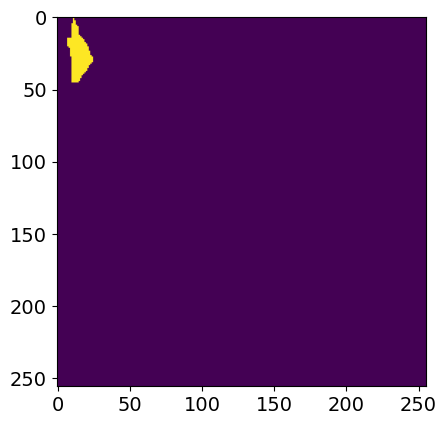

In [38]:
import re

from PIL import Image
import math
from skimage.morphology import remove_small_objects
def seg_crack(img_rgb):
    img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
    lower_red = np.array([200, 0, 0])      # closer to pure red
    upper_red = np.array([255, 80, 80])    # allow only a little green/blue
    
    mask = cv2.inRange(img_rgb, lower_red, upper_red)
    red_only = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)
    red_mask=np.where(red_only[:,:,0]!=0,255,0)
    return red_mask

raw_img=[[[] for i in range(2)] for j in range(3)]
length_img=[[[] for i in range(2)] for j in range(3)]
length_prop=[[[] for i in range(2)] for j in range(3)]
width_img=[[[] for i in range(2)] for j in range(3)]
density=[[[] for i in range(2)] for j in range(3)]
from pathlib import Path
all_gen_path = [
    i for i in (Path("/home/jixi/project/genai/output_conditional_unet_aggexp_embed_full_x0pred_cldice6/generated_masks").glob("*_mask.png"))
    if not i.stem.endswith("_dilated_mask")
]
print(all_gen_path)
out_img_path=Path("/home/jixi/project/genai/output_conditional_unet_aggexp_embed_full_x0pred_cldice6/generated_masks/Evaluation_generation")
for i in all_gen_path:
    name=i.stem
    exp=int(re.search(r"_exp([^_]+)_", name).group(1))
    
    agg=int(name[1])-1
    if agg>2:
        agg=2
    print(name,exp,agg)
    cracks=Image.open(i).convert("L")
    mask = np.asarray(cracks) >240
    cleaned = remove_small_objects(mask, min_size=5)
    raw_img[agg][exp].append(np.array(cleaned))
for j in range(3):
    for i in range(2):
        for k in range(len(raw_img[j][i])):
            seg=raw_img[j][i][k]
            plt.imshow(seg)
            a,b=seg.shape
            crack_den=np.sum(seg)/(a*b)
            density[j][i].append(crack_den)
            thk,psd=meausure_thickness(seg,18)
            width_img[j][i].append(thk)
            skele=denoise_skeletonize(seg)
            table,img_l=measure_length(skele.astype('uint8'),18)
            length_img[j][i].append(img_l)
            length_prop[j][i].append(table)


In [39]:
import os
os.makedirs(out_img_path, exist_ok=True)

In [14]:
length_img

[[[], []], [[], []], [[], []]]

0 0 0
0 0 1
0 0 2
0 0 3
0 0 4
0 0 5
0 0 6
0 0 7
0 0 8
0 0 9
0 0 10
0 0 11
0 0 12
0 0 13
0 1 0
0 1 1
0 1 2
0 1 3
0 1 4
0 1 5
0 1 6
0 1 7
0 1 8
0 1 9
0 1 10
0 1 11
0 1 12
0 1 13
1 0 0
1 0 1
1 0 2
1 0 3
1 0 4
1 0 5
1 0 6
1 0 7
1 0 8
1 0 9
1 0 10
1 0 11
1 1 0
1 1 1
1 1 2
1 1 3
1 1 4
1 1 5
1 1 6
1 1 7
1 1 8
1 1 9
1 1 10
1 1 11
1 1 12
1 1 13
1 1 14
1 1 15
1 1 16
1 1 17
2 0 0
2 0 1
2 0 2
2 0 3
2 0 4
2 0 5
2 0 6
2 0 7
2 0 8
2 0 9
2 0 10
2 0 11
2 0 12
2 0 13
2 0 14
2 0 15
2 0 16
2 0 17
2 0 18
2 0 19
2 0 20
2 0 21
2 0 22
2 0 23
2 0 24
2 0 25
2 1 0
2 1 1
2 1 2
2 1 3
2 1 4
2 1 5
2 1 6
2 1 7
2 1 8
2 1 9
2 1 10
2 1 11
2 1 12
2 1 13
2 1 14
2 1 15


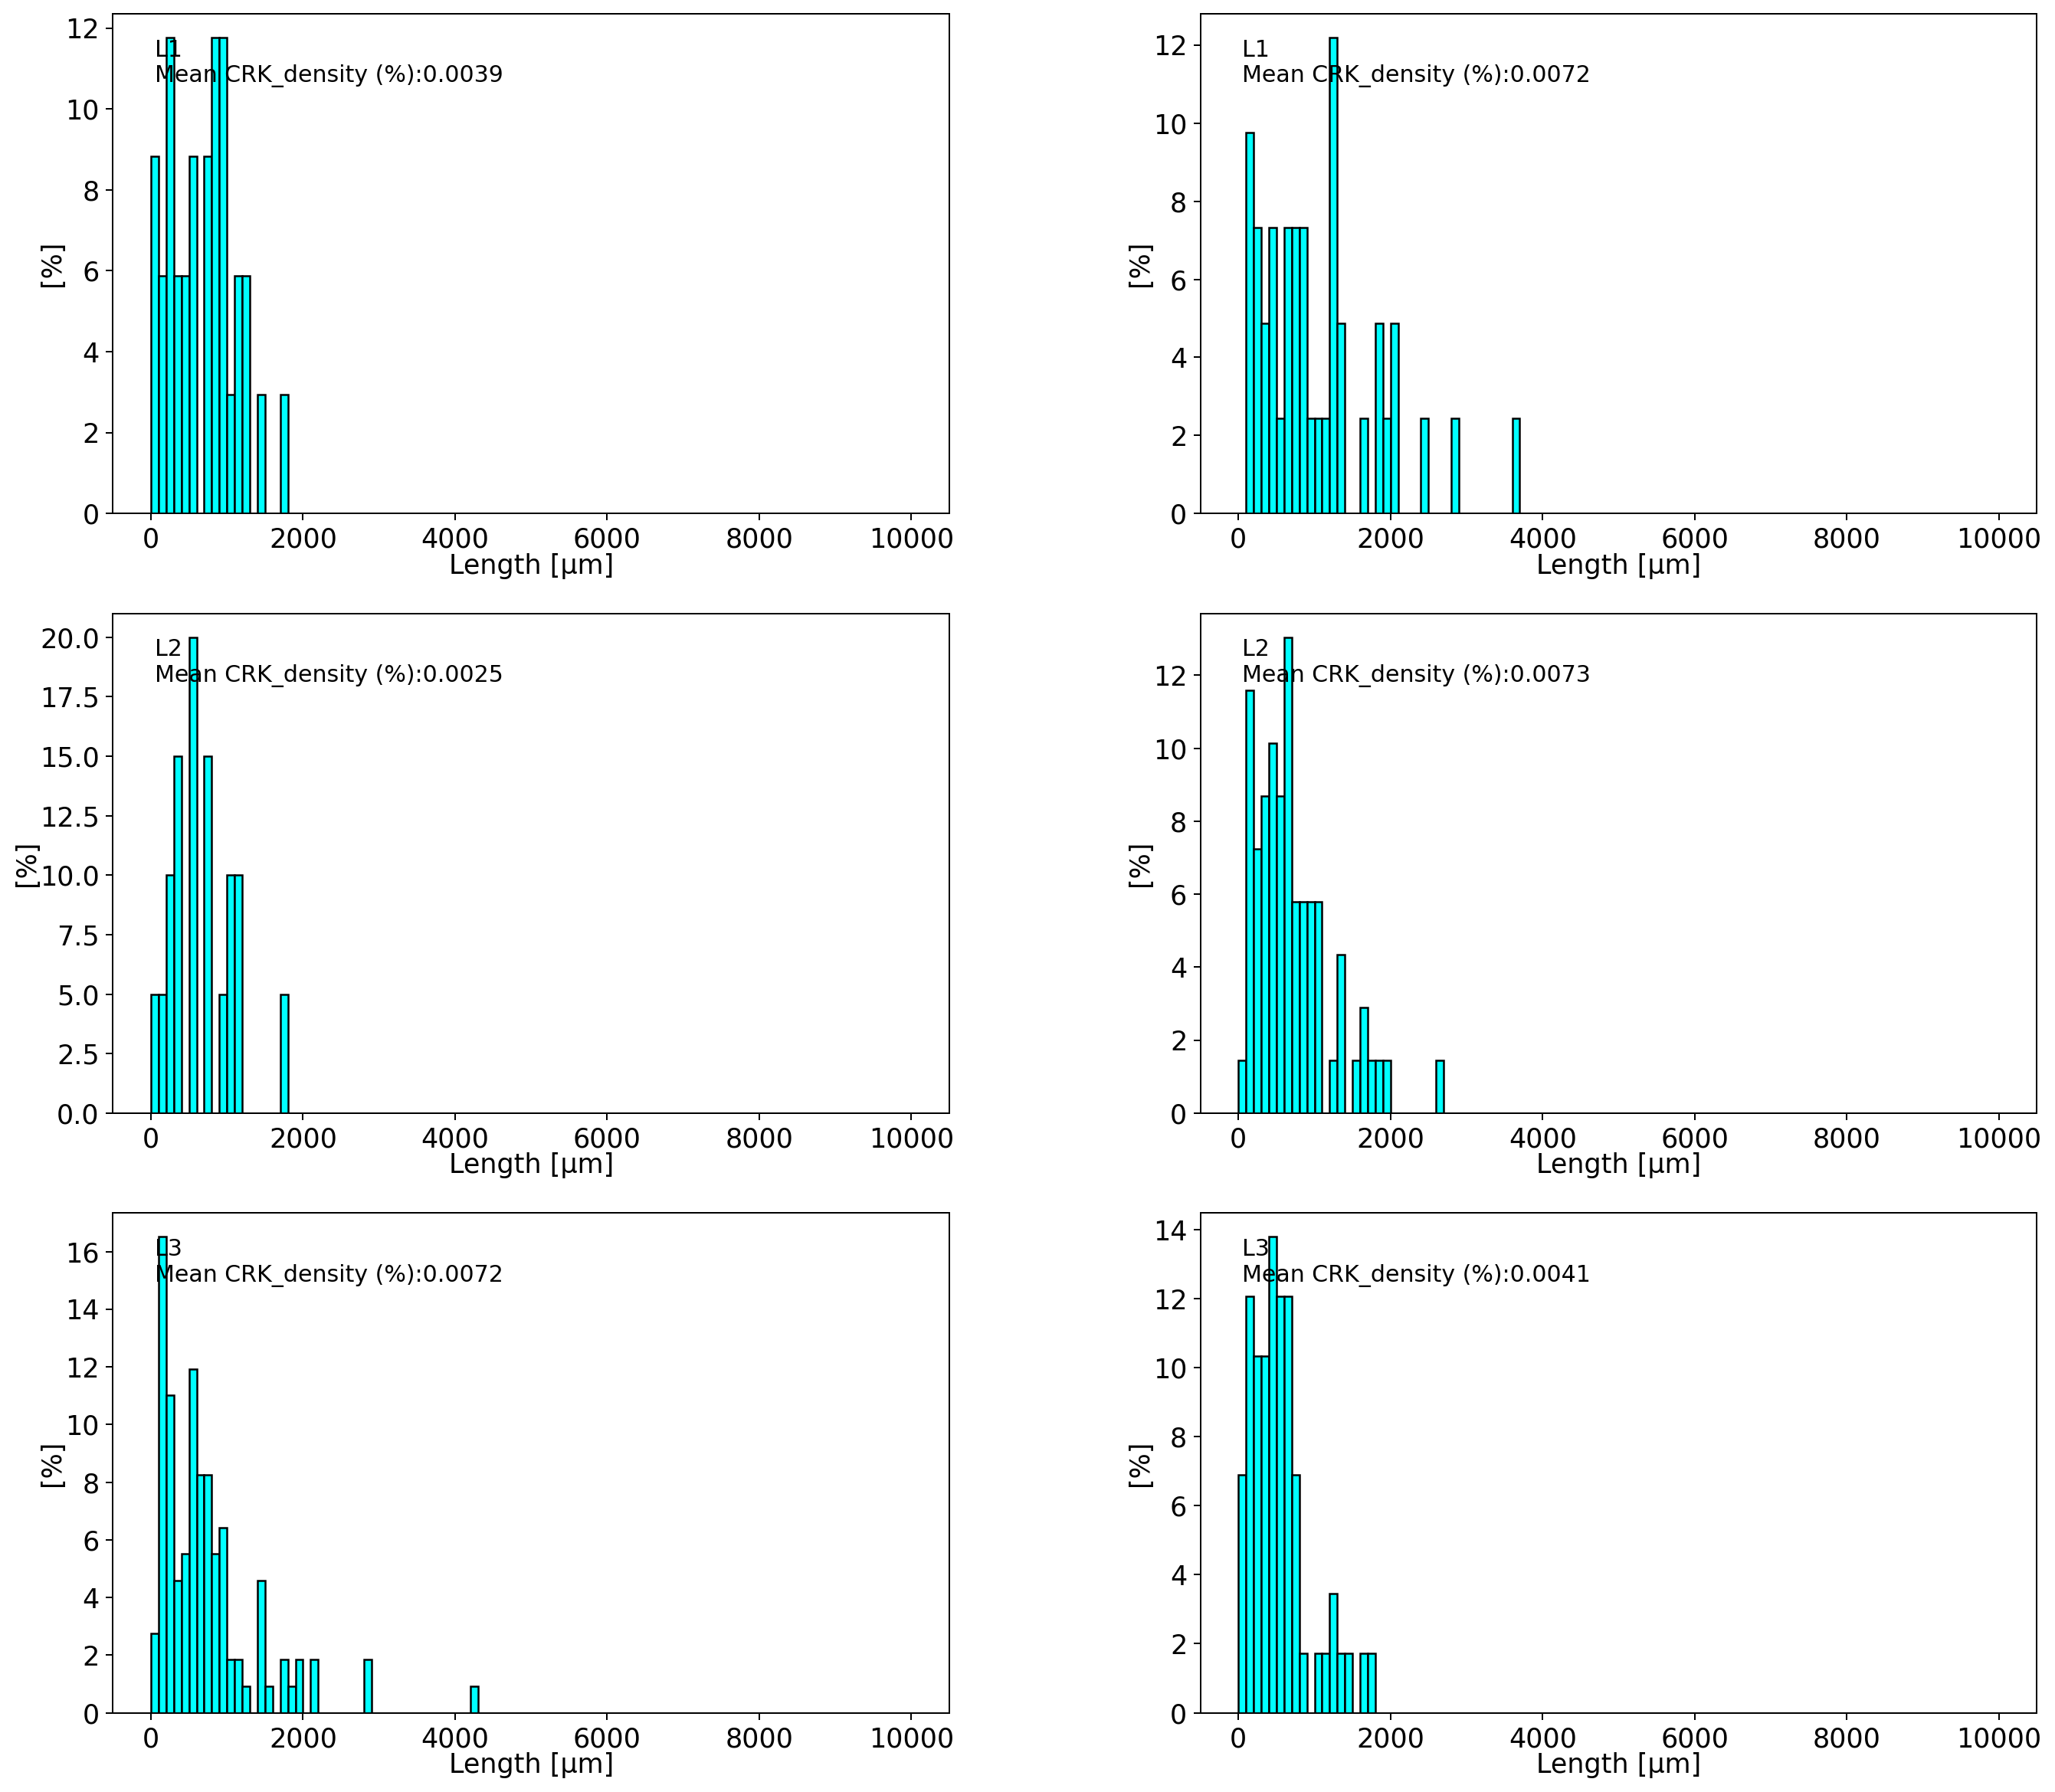

In [42]:
#Count width (Group average)
plt.rcParams['font.size']=14
fig,ax1=plt.subplots(ncols=2,nrows=3,figsize=(15,16),dpi=180)
for i in range(3):
    for j in range(2):
        group_w=np.array([])
        means=[]
        for k in range(len(width_img[i][j])):
            print(i,j,k)
            nonzero_values = width_img[i][j][k][width_img[i][j][k]!= 0]
            group_w=np.concatenate([group_w,nonzero_values.ravel()])
            means.append(density[i][j][k])
        weights = np.ones_like(group_w) / len(group_w)*100
        ax1[i][j].hist(group_w, bins=np.arange(0,610,10),
                       weights=weights,
                       cumulative=False,
                       density=False,
                       color="cyan", edgecolor="black")
        mean_v=np.mean(np.array(means))
        ax1[i][j].text(0.05, 0.95, f"L{i+1}\nMean CRK_density (%):{mean_v/255*100:.4f}", transform=ax1[i][j].transAxes, fontsize=12, verticalalignment='top')
        #ax1[i][j].set_xlim(0,200)
        #ax1[i][j].set_ylim(0,1)
        ax1[i][j].set_xlabel("Width [\u03bcm]",labelpad=0)
        ax1[i][j].set_ylabel("[%]",labelpad=0)
plt.subplots_adjust(wspace=0.3, hspace=0.2)
plt.savefig(out_img_path/'Width_gen.png',bbox_inches='tight')
plt.close("all")
plt.rcParams['font.size']=14
#Count width (Group average)
#Count width (Group average)
fig,ax1=plt.subplots(ncols=2,nrows=3,figsize=(18,16),dpi=180)
for i in range(3):
    for j in range(2):
        group_l=np.array([])
        means=[]
        for k in range(len(length_img[i][j])):
            #nonzero_values = length_img[i][j][k][length_img[i][j][k]!= 0]
            #group_l=np.concatenate([group_l,nonzero_values.ravel()])
            means.append(density[i][j][k])
            area_vals = np.asarray(length_prop[i][j][k]["area"])
            group_l=np.concatenate([group_l,area_vals])
        weights = np.ones_like(group_l) / len(group_l)*100
        ax1[i][j].hist(group_l, bins=np.arange(0,10100,100),
                       weights=weights,
                       cumulative=False,
                       density=False,
                       color="cyan", edgecolor="black")
        mean_v=np.mean(np.array(means))
        ax1[i][j].text(0.05, 0.95, f"L{i+1}\nMean CRK_density (%):{mean_v/255*100:.4f}", transform=ax1[i][j].transAxes, fontsize=12, verticalalignment='top')
        #ax1[i][j].set_xlim(0,4000)
        #ax1[i][j].set_ylim(0,1)
        ax1[i][j].set_xlabel("Length [\u03bcm]",labelpad=0)
        ax1[i][j].set_ylabel("[%]",labelpad=0)
plt.subplots_adjust(wspace=0.3, hspace=0.2)
plt.savefig(out_img_path/'Length_gen.png',bbox_inches='tight')    

0 3
L101_U0_Simple Segmentation_ck_dn
1 0
L111_U0_Simple Segmentation_ck_dn
1 1
L111_U1_Simple Segmentation_ck_dn
1 2
L111_U2_Simple Segmentation_ck_dn-1
1 3
L111_U2_Simple Segmentation_ck_dn
1 4
L112_U0_Simple Segmentation_ck_dn
1 5
L112_U1_Simple Segmentation_ck_dn
1 6
L112_U2_Simple Segmentation_ck_dn
2 0
L123_U0_Simple Segmentation_ck_dn
2 1
L123_U1_Simple Segmentation_ck_dn
2 2
L123_U2_Simple Segmentation_ck_dn
3 0
L133_U0_Simple Segmentation_ck_dn
3 1
L133_U1_Simple Segmentation_ck_dn
3 2
L133_U2_Simple Segmentation_ck_dn
0 0
L201_U0_Simple Segmentation_ck_dn
0 1
L201_U1_Simple Segmentation_ck_dn
0 2
L201_U2_Simple Segmentation_ck_dn
1 0
L211_U0_Simple Segmentation_ck_dn
1 1
L211_U1_Simple Segmentation_ck_dn
1 2
L211_U2_Simple Segmentation_ck_dn
1 3
L212_U0_Simple Segmentation_ck_dn
1 4
L212_U1_Simple Segmentation_ck_dn
2 0
L222_U0_Simple Segmentation_ck_dn
2 1
L222_U2_Simple Segmentation_ck_dn
3 0
L231_U0_Simple Segmentation_ck_dn
3 1
L231_U1_Simple Segmentation_ck_dn
3 2
L231_U

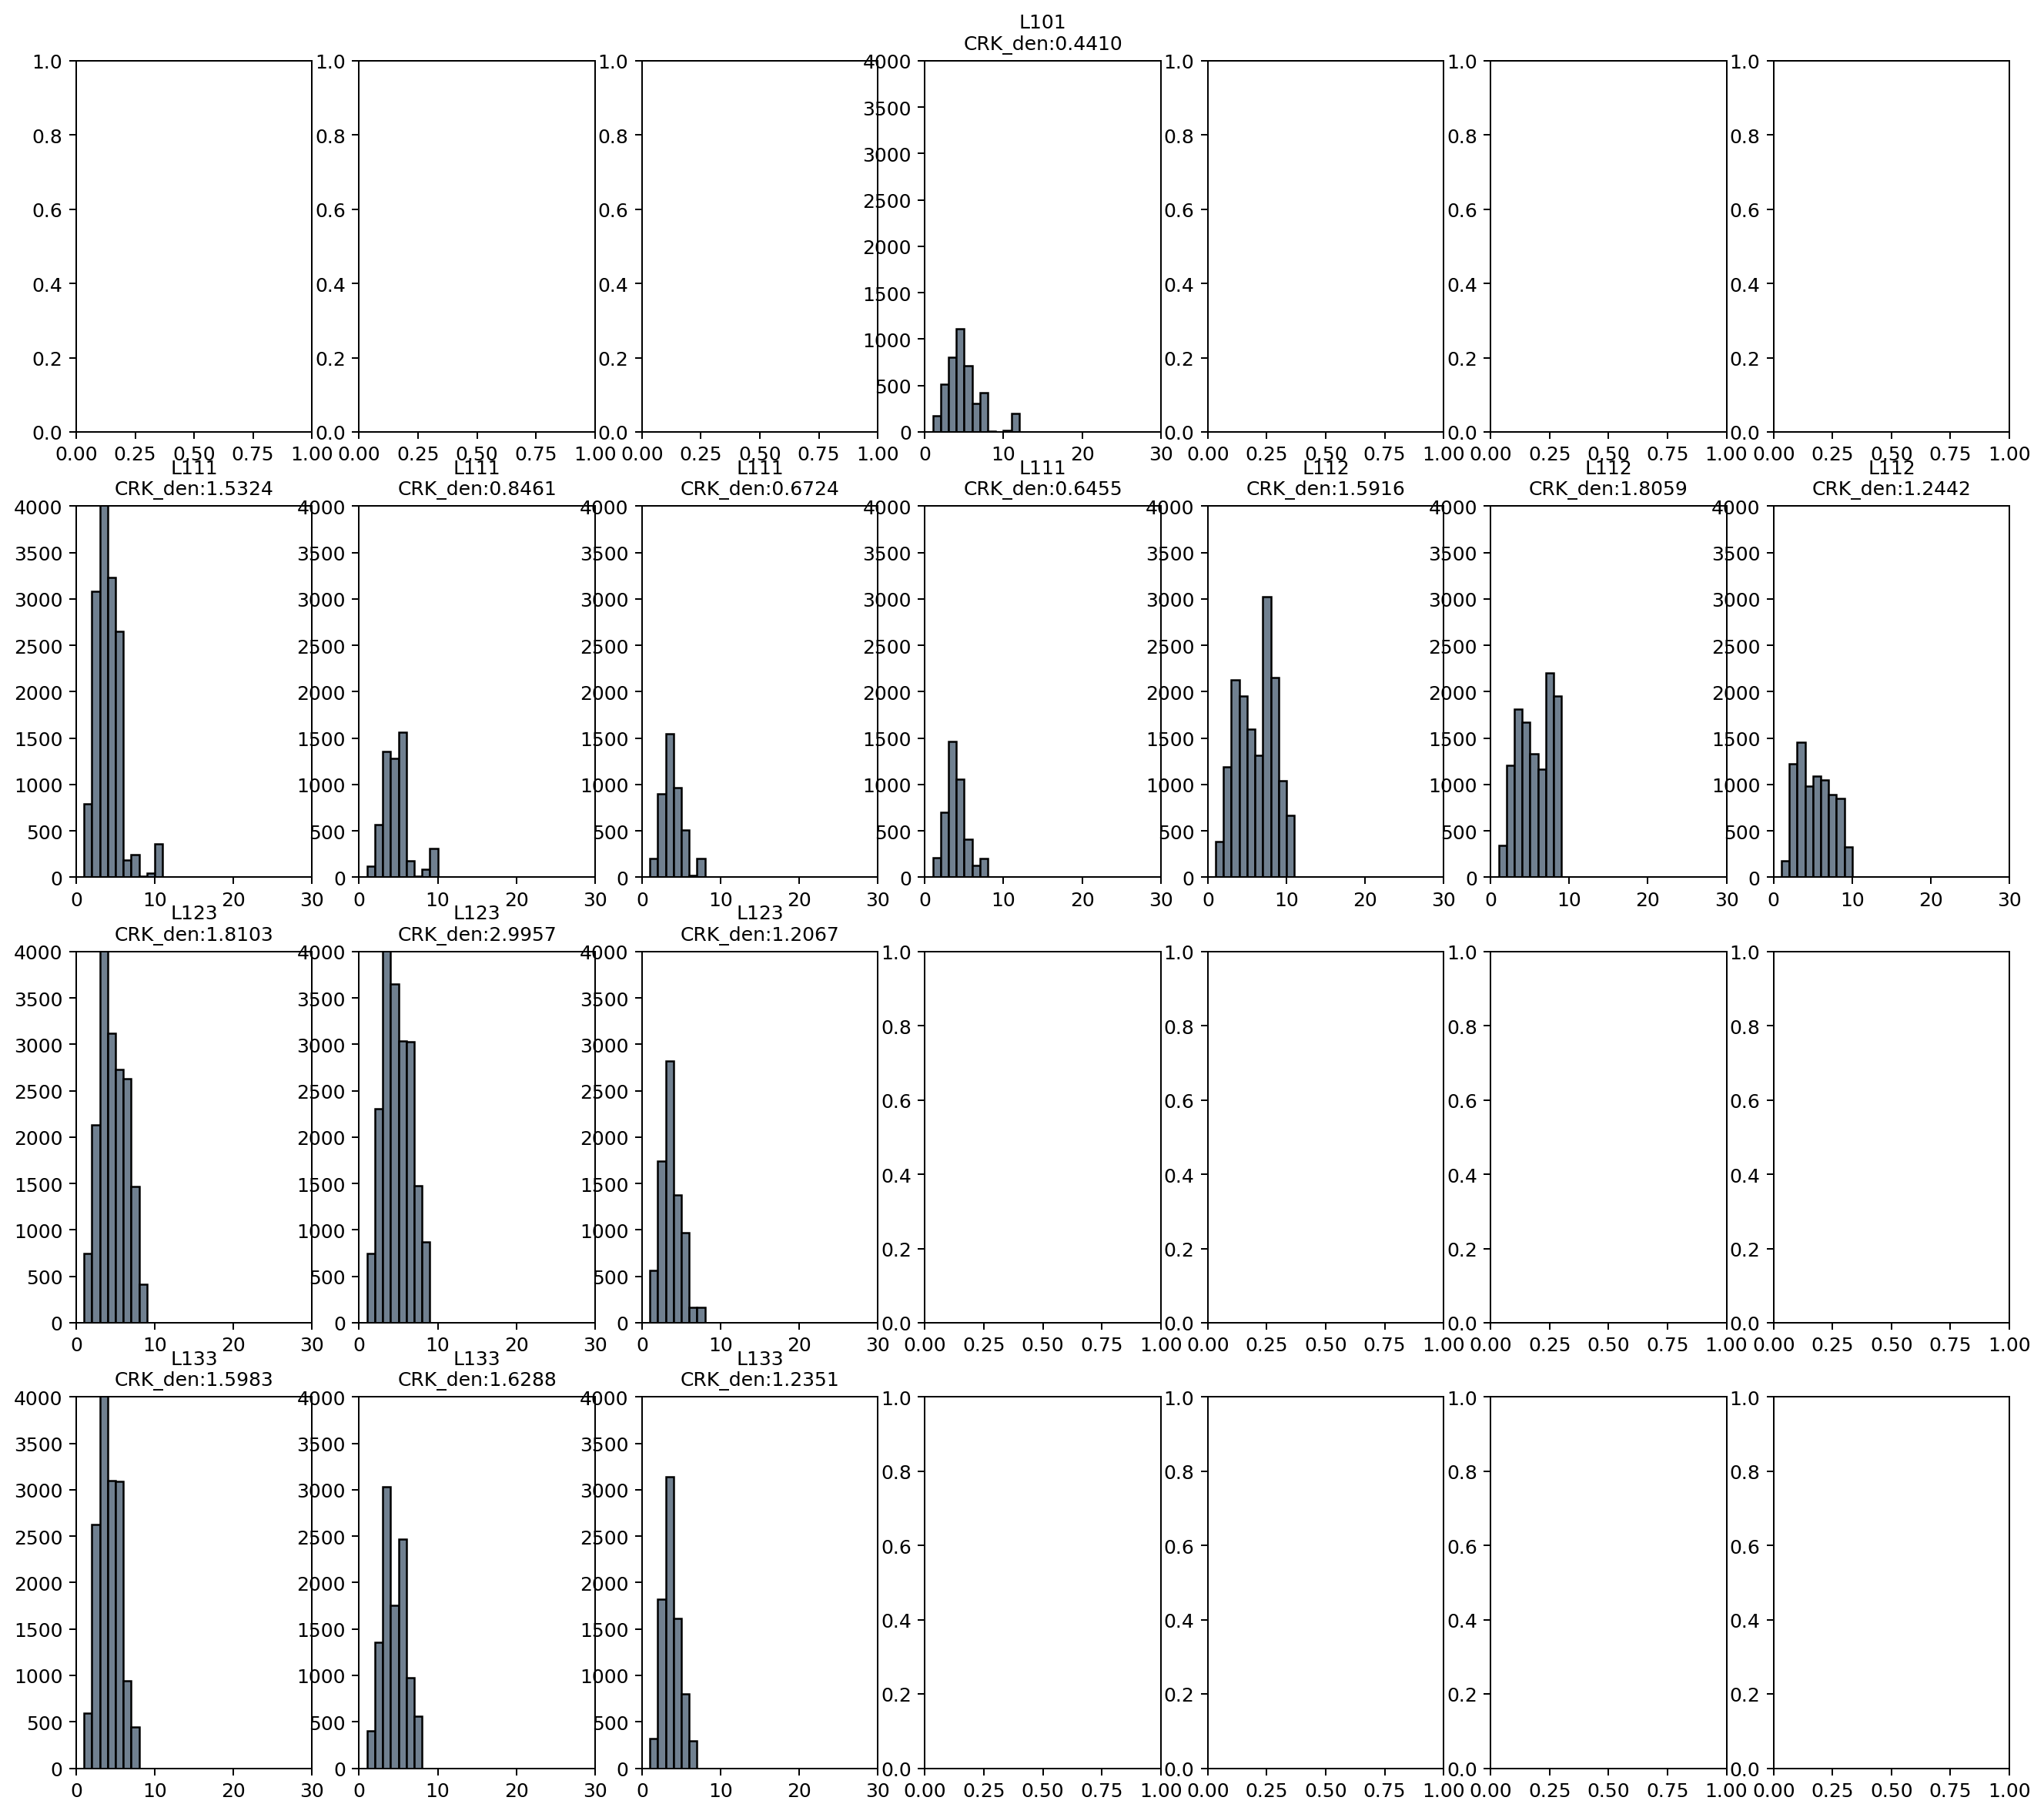

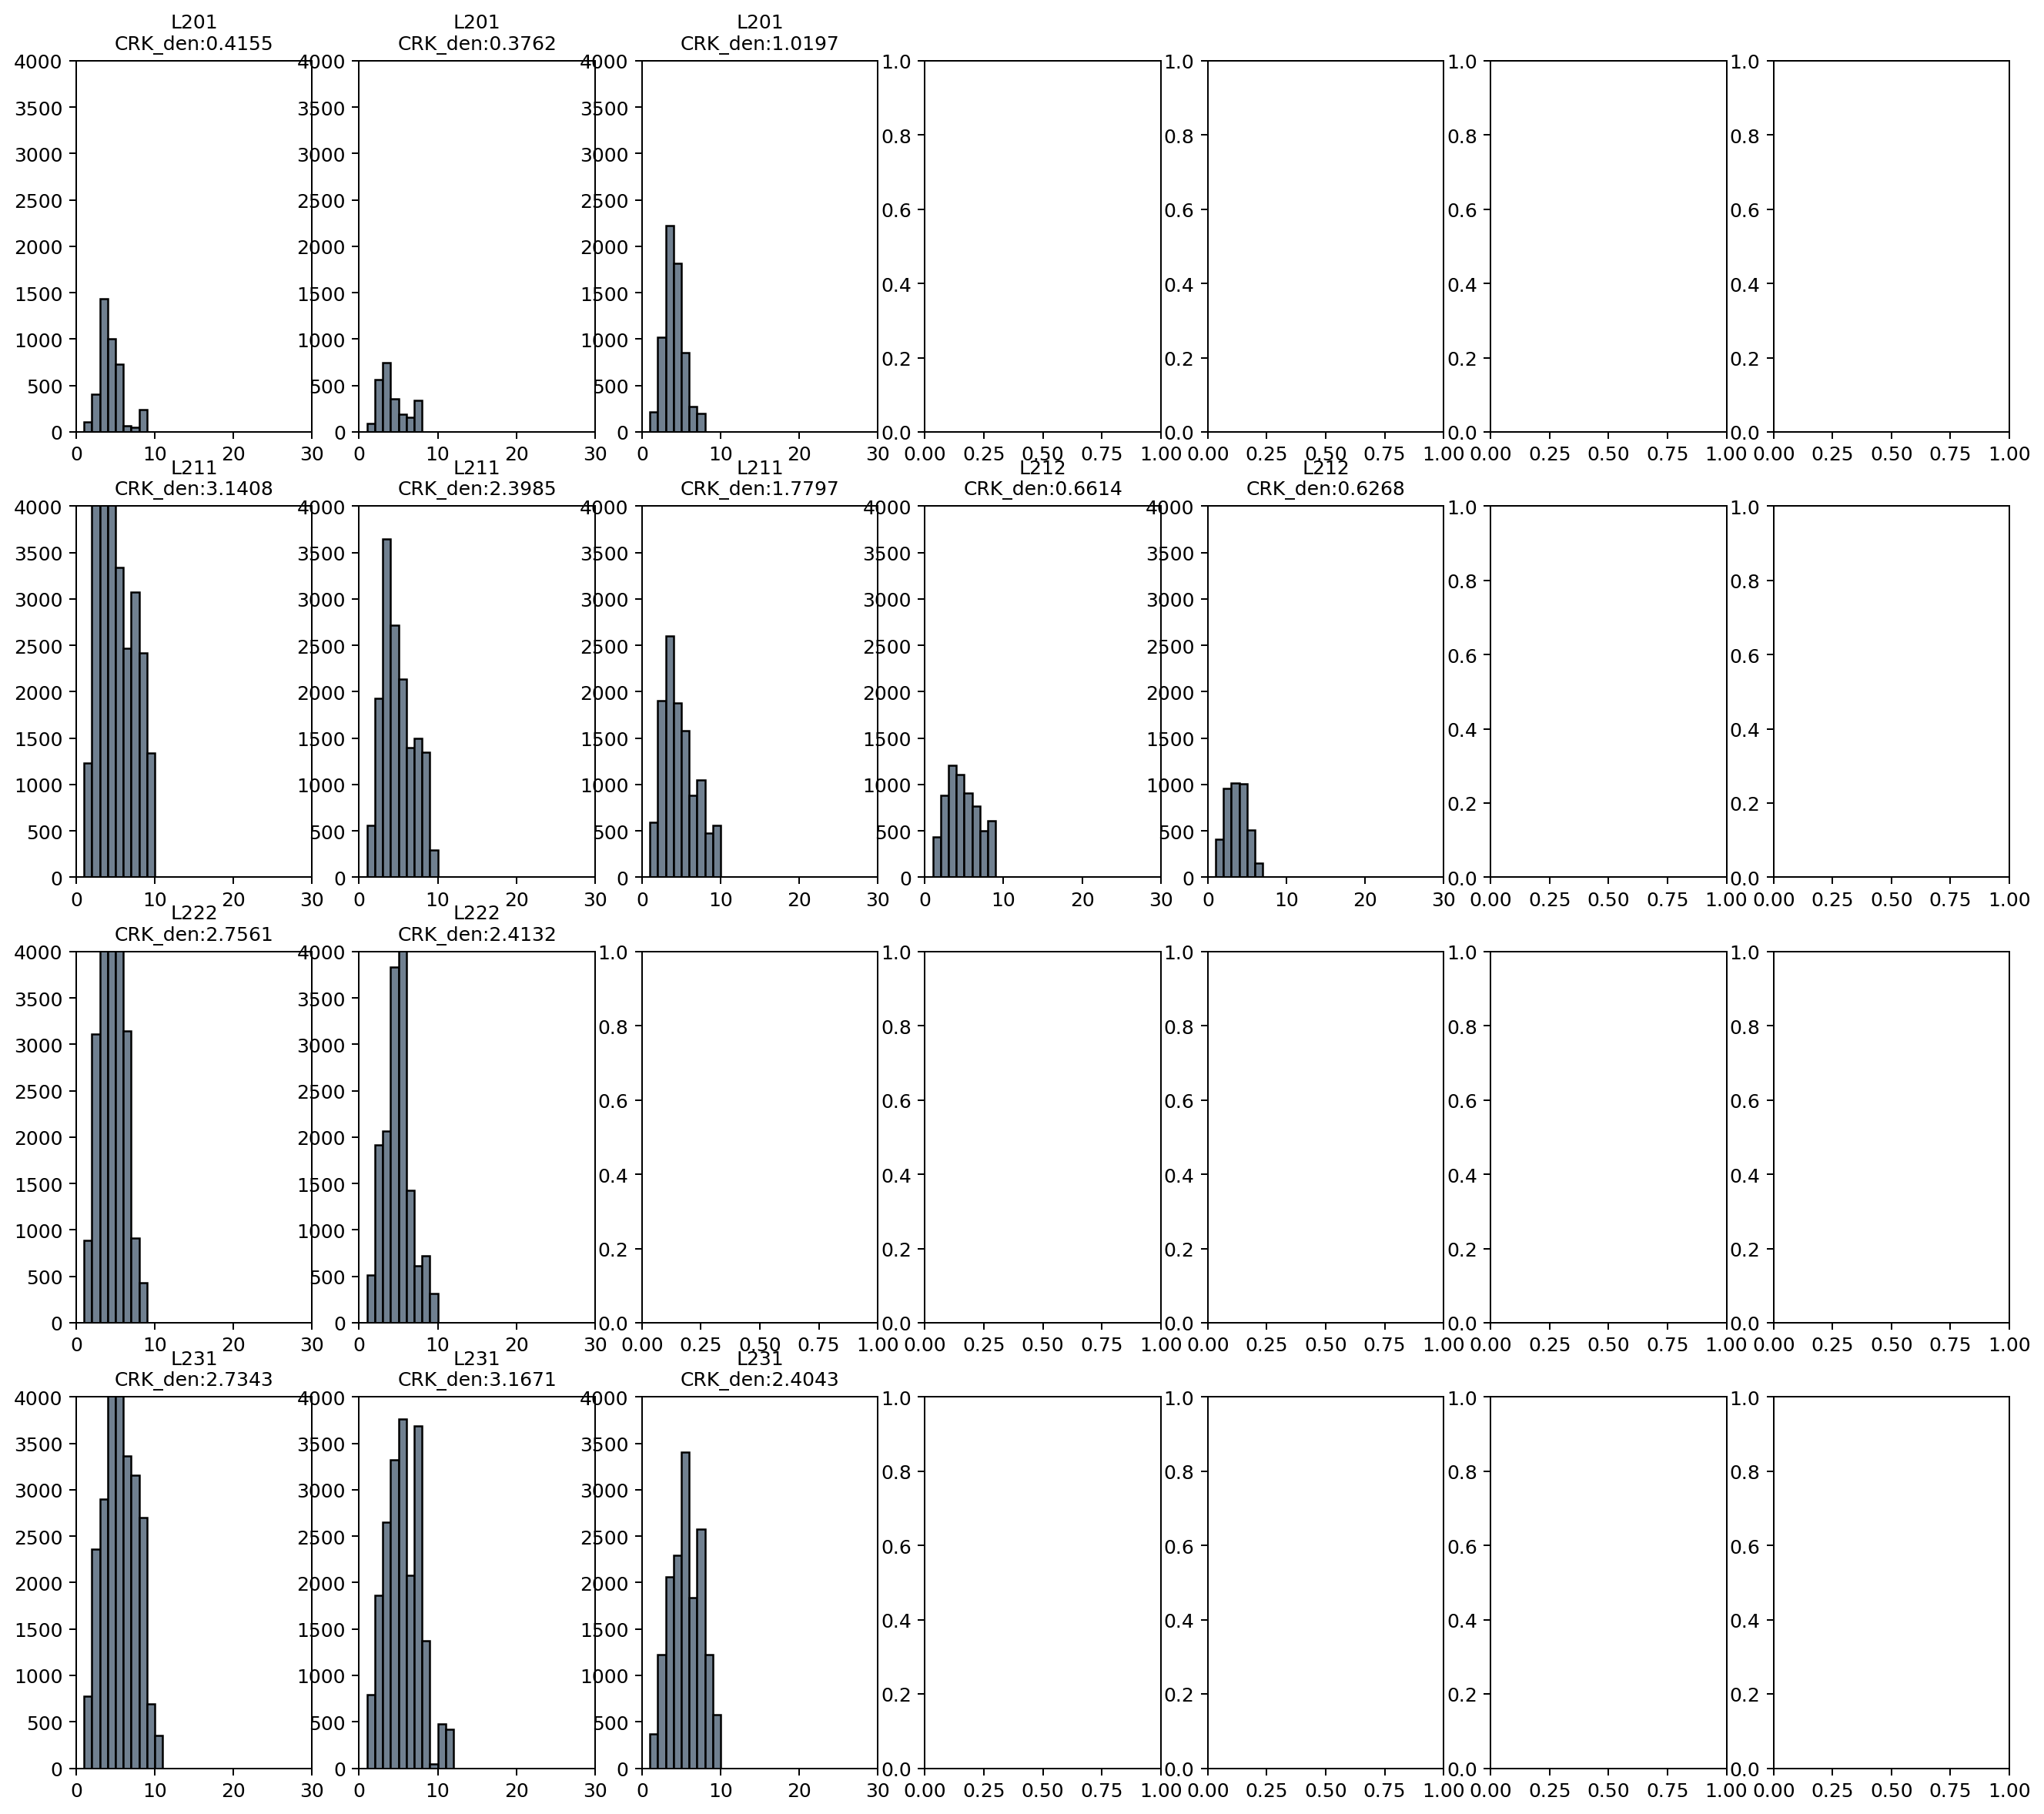

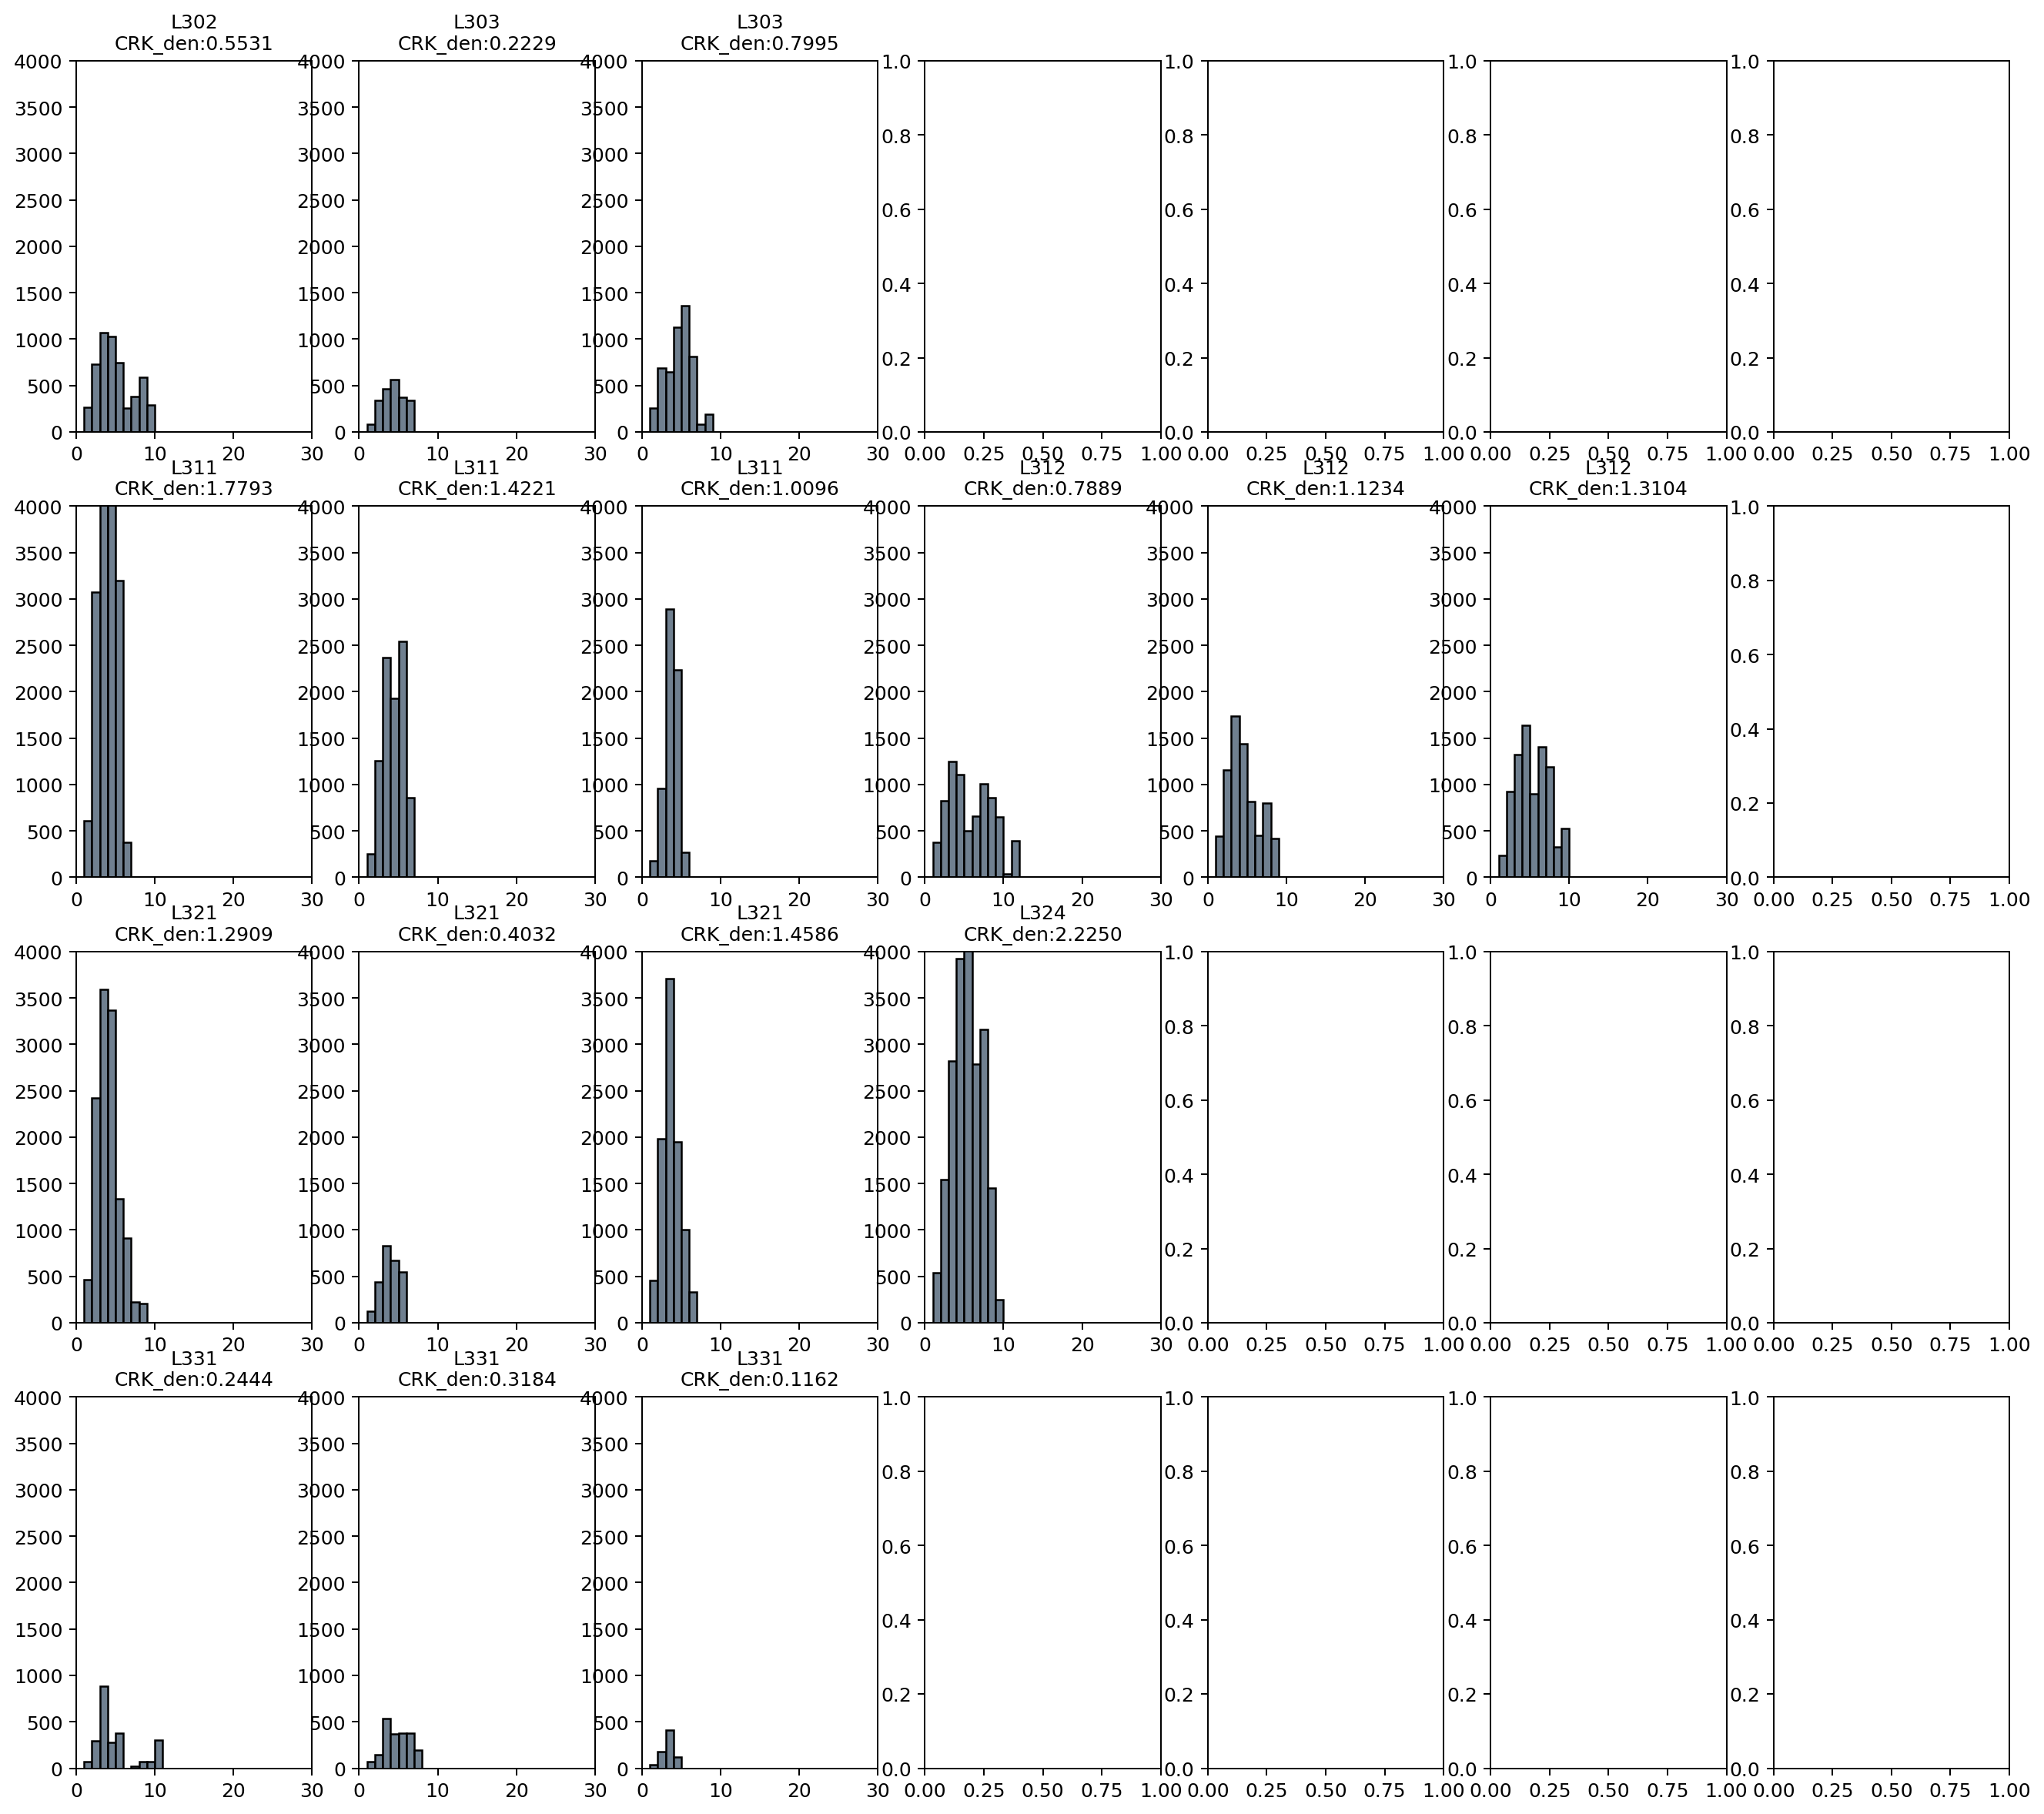

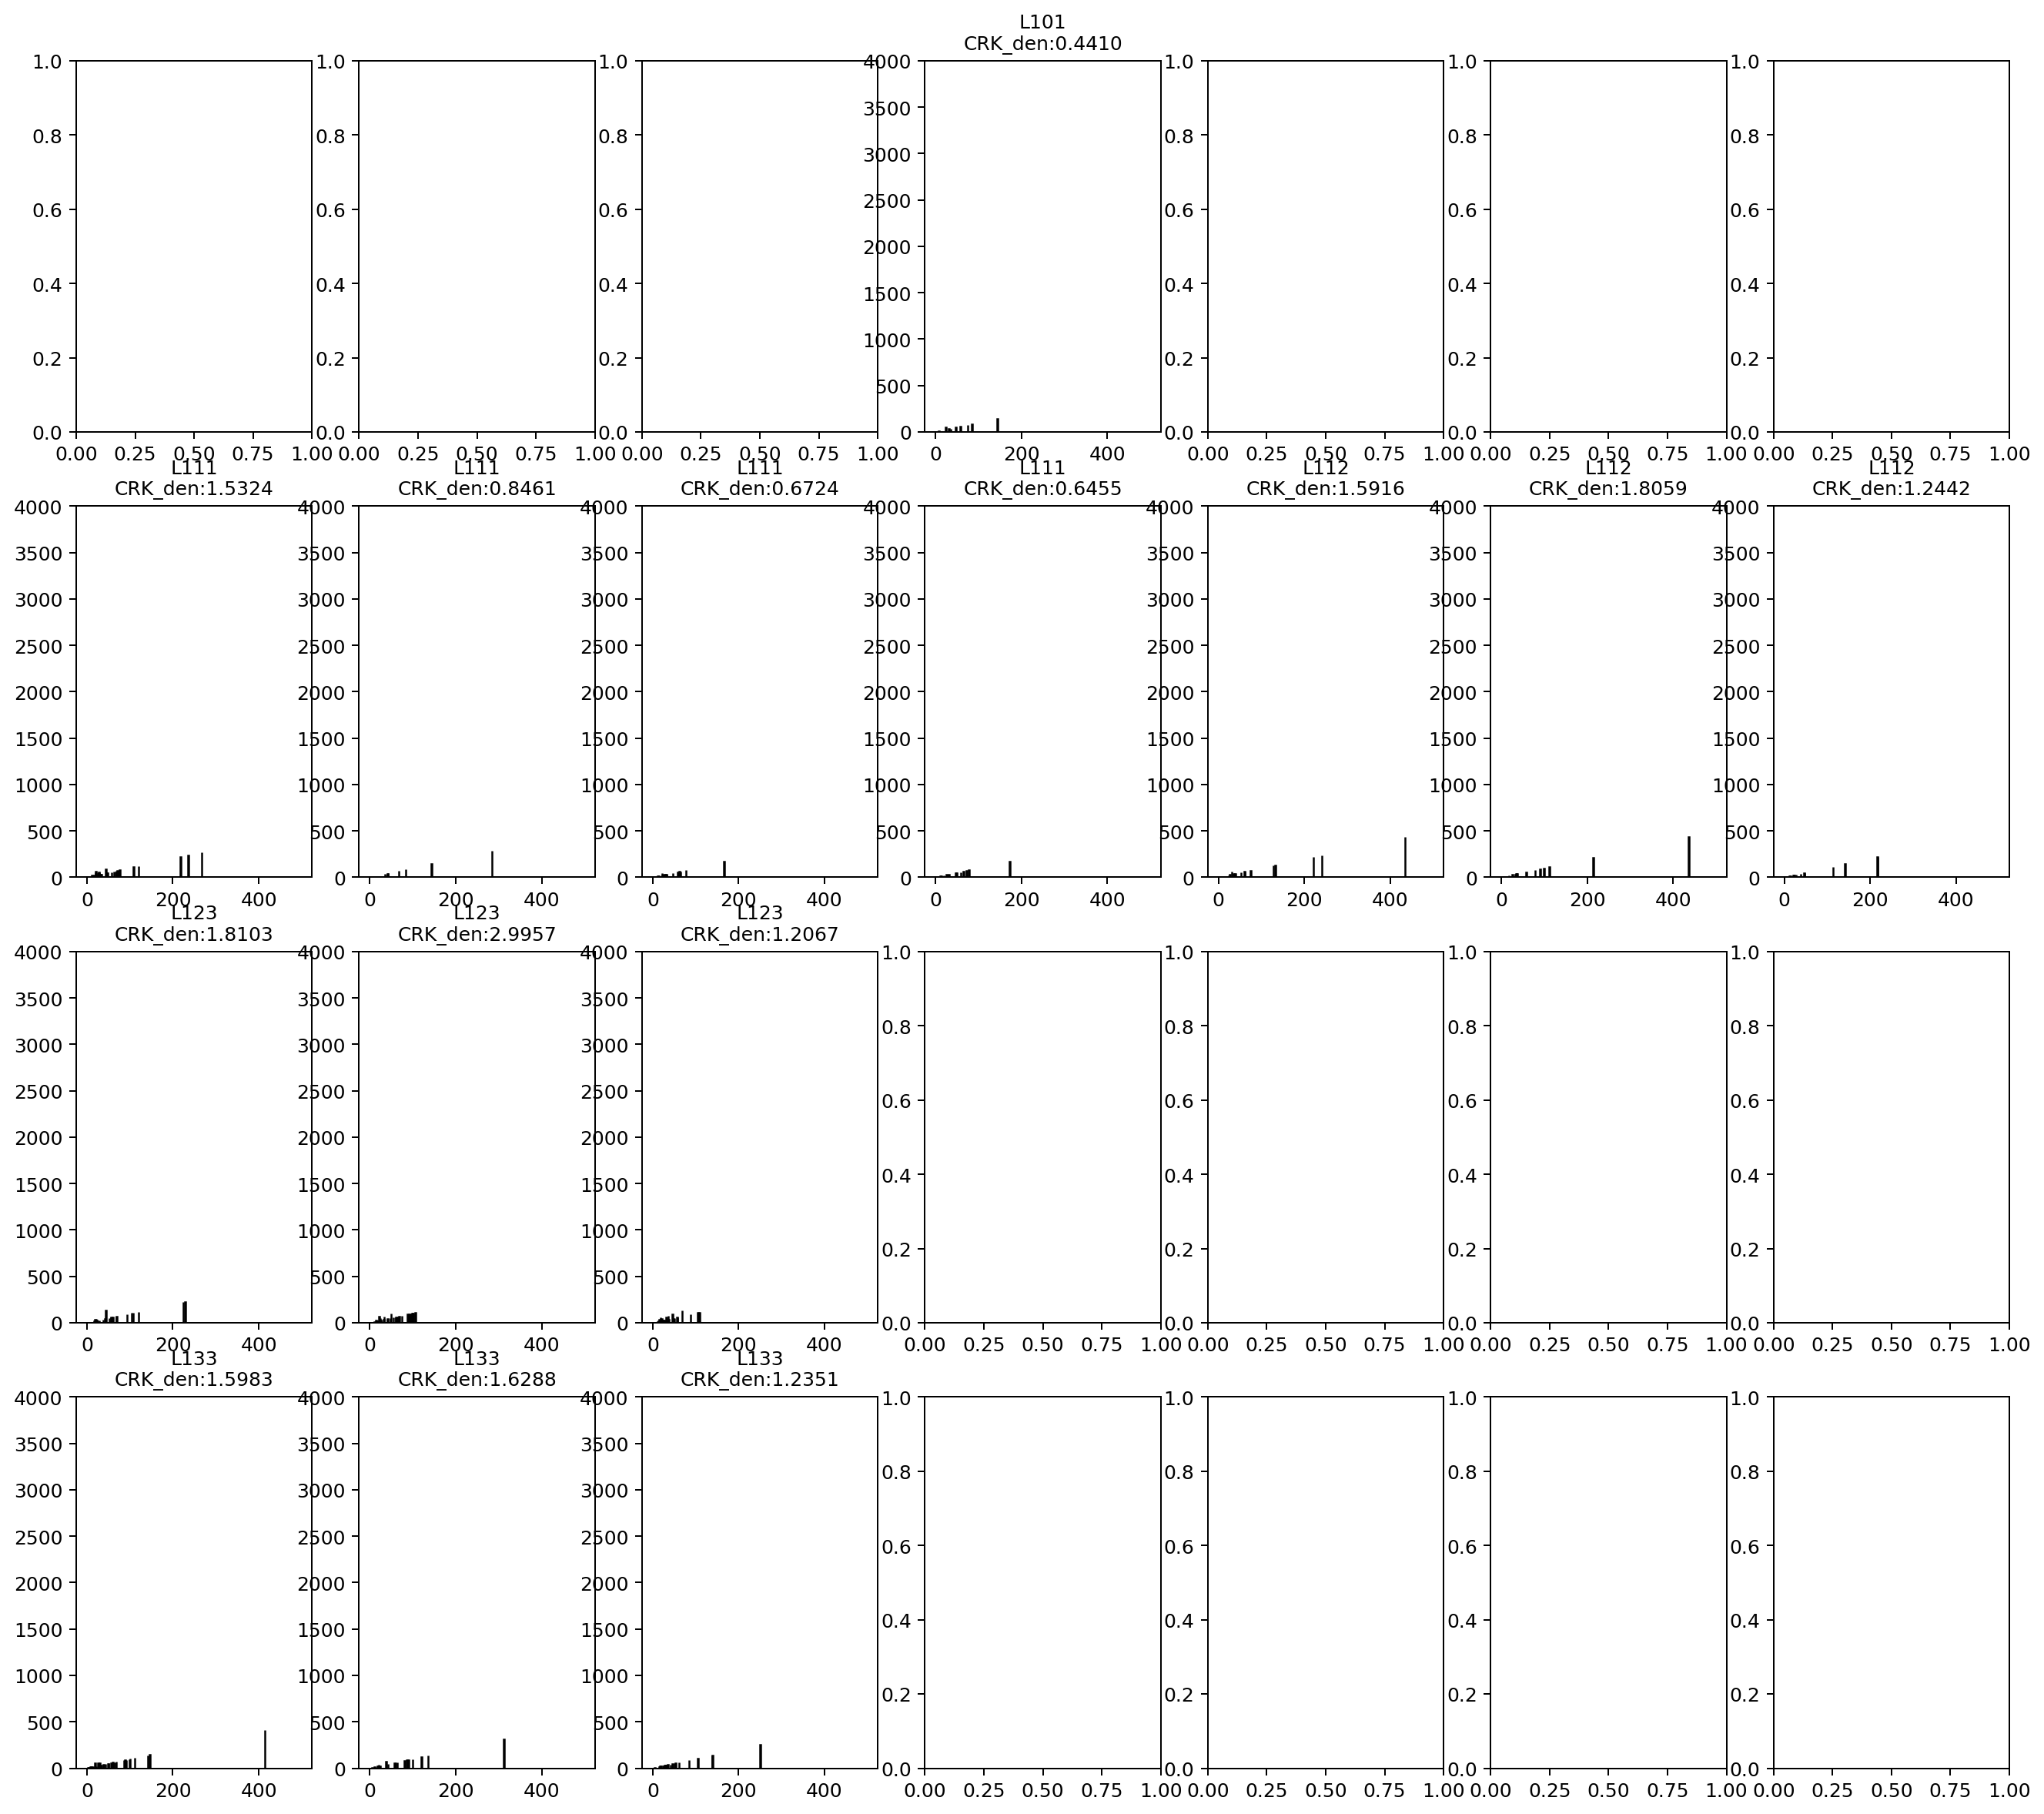

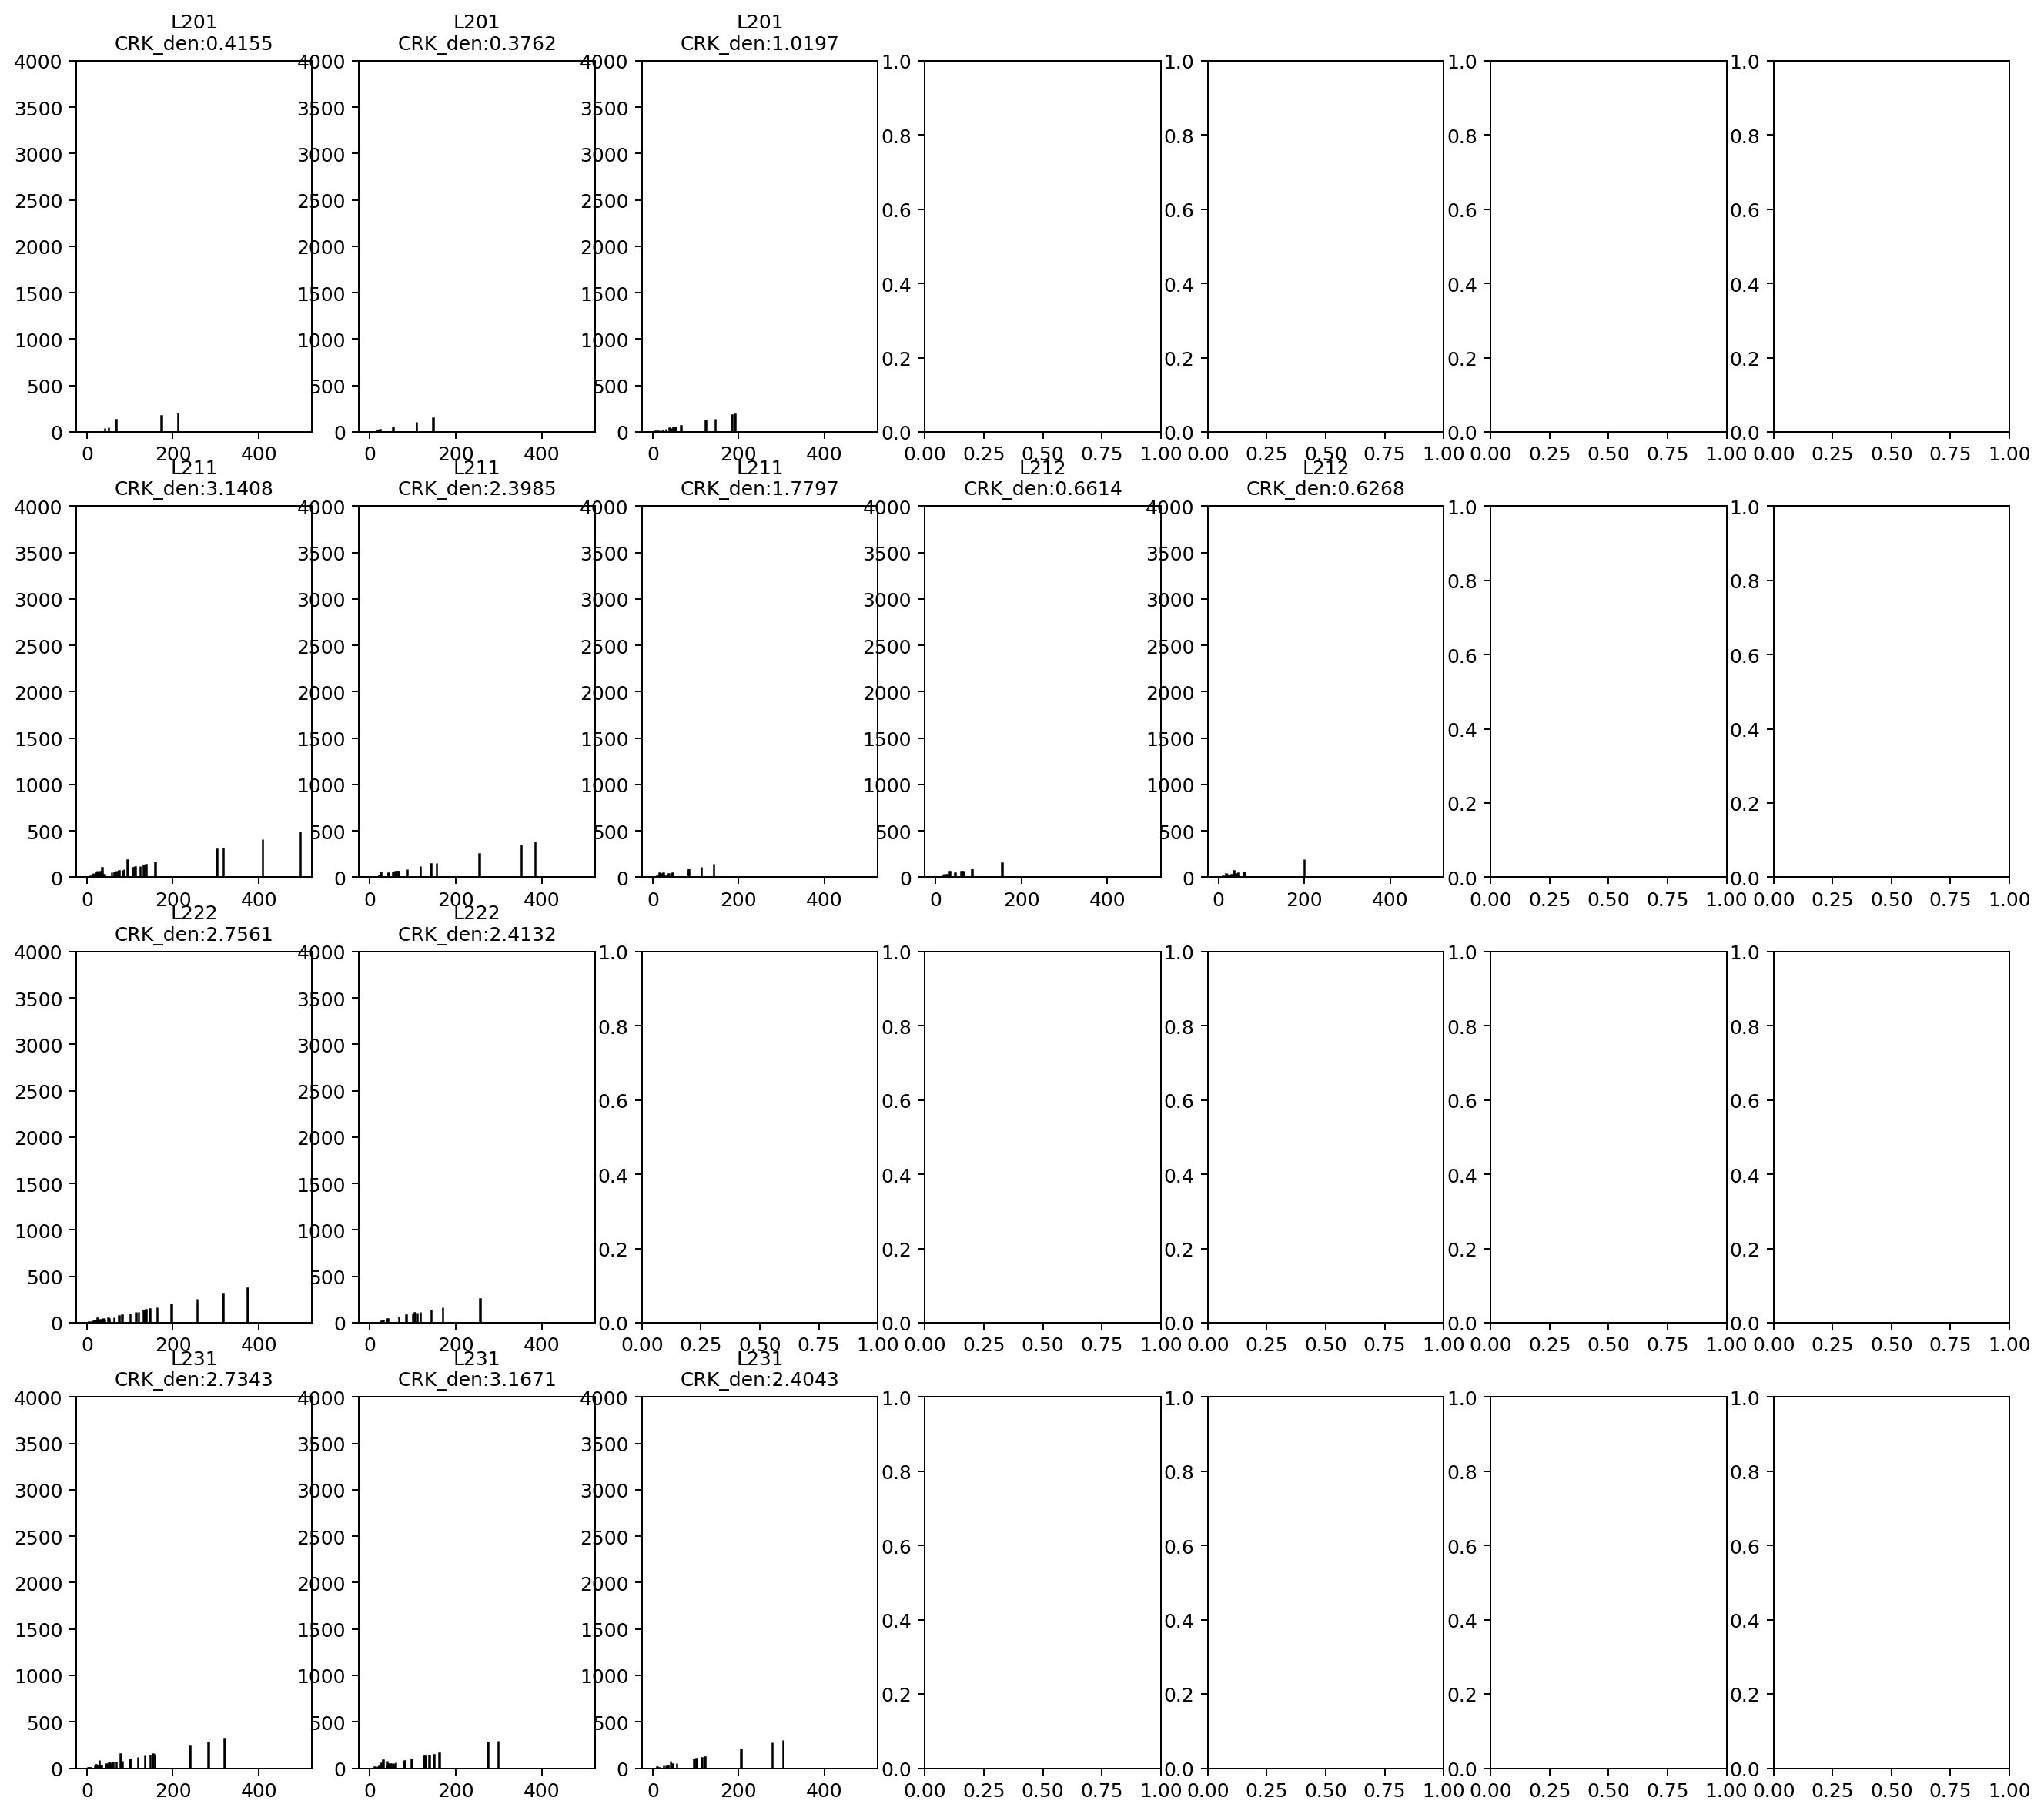

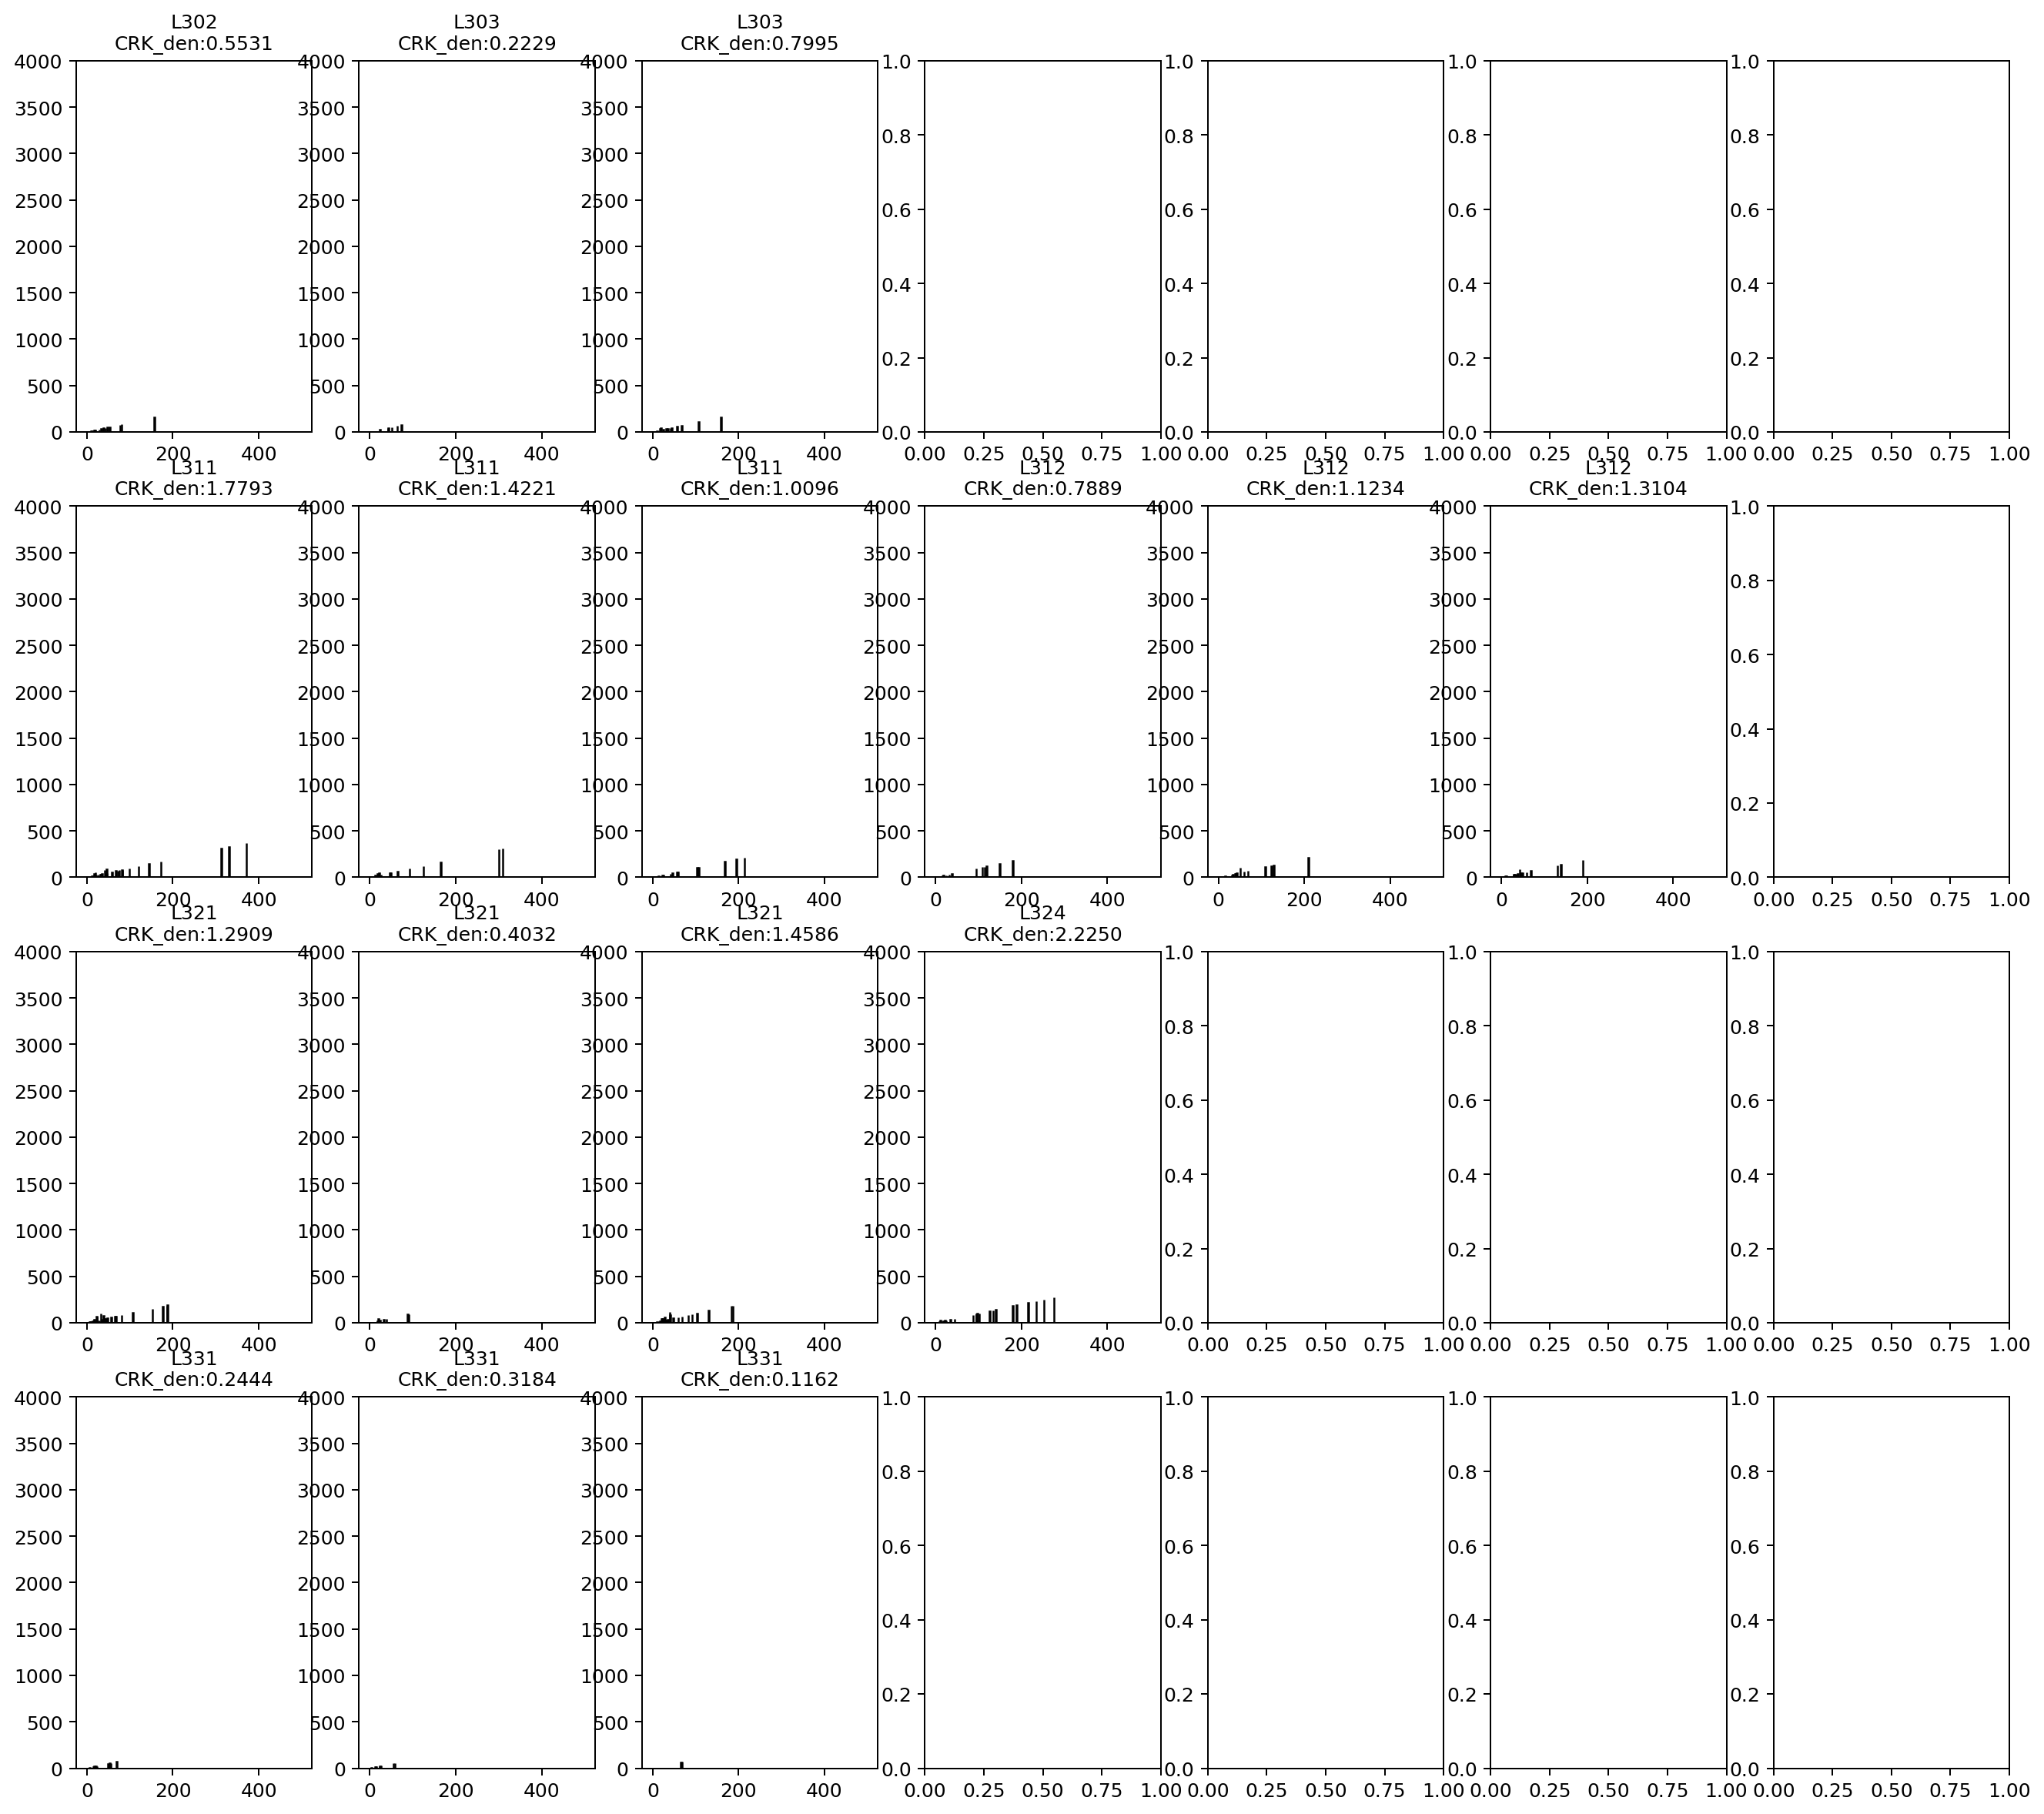

In [100]:
#Count length width
for i in range(len(records)):
    fig,ax1=plt.subplots(ncols=7,nrows=4,figsize=(18,16),dpi=180)
    for j in range(len(records[i])):
        for k in range(len(records[i][j])):
            nonzero_values = width[i][j][k][width[i][j][k] != 0]
            if nonzero_values.size == 0:
                continue
            else:
                print(j,k)
                print(records[i][j][k]["image_name"])
                
                ax1[j][k].hist(nonzero_values.ravel(), bins=np.arange(0,60), color="slategray", edgecolor="black")
                ax1[j][k].set_title(f"{records[i][j][k]["image_name"][:4]}\nCRK_den:{density[i][j][k]:.4f}",fontsize=10)
                ax1[j][k].set_xlim(0,30)
                ax1[j][k].set_ylim(0,4000)
    plt.savefig(f"Width_L{i+1}.png",bbox_inches='tight')
#Count width
for i in range(len(records)):
    fig,ax1=plt.subplots(ncols=7,nrows=4,figsize=(18,16),dpi=180)
    for j in range(len(records[i])):
        for k in range(len(records[i][j])):
            nonzero_values = length[i][j][k][length[i][j][k] != 0]
            if nonzero_values.size == 0:
                continue
            else:
                print(j,k)
                print(records[i][j][k]["image_name"])
                
                ax1[j][k].hist(nonzero_values.ravel(), bins=np.arange(0,500), color="slategray", edgecolor="black")
                ax1[j][k].set_title(f"{records[i][j][k]["image_name"][:4]}\nCRK_den:{density[i][j][k]:.4f}",fontsize=10)
                #ax1[j][k].set_xlim(0,30)
                ax1[j][k].set_ylim(0,4000)
    plt.savefig(f"Length_L{i+1}.png",bbox_inches='tight')
        

[ 26.  20.  44.  43. 139. 106.  23.  14.  26.  36. 122.  16.  33.  17.
  31.  48.  25.  17.  19.   7.  10.  74.  18.  65.  39.  74.  23.  62.
   6.  16.  15.  11. 104.  24.  17.  29.  35.  16.  23.  10.  35.  50.
  83. 108.  16.   7.  51.  51.  11. 171.  17.  10.  47.  28.  22. 144.
   5.  67.  16.   6.   9.  57.   6.  17.  66.   8.  17. 193.  57.  95.
  18.   9.  18.   8.  48. 100. 130.  97. 225.  23.  34.  22.  49.  18.
  38.  20. 114.  14.  27.  42.  27.  41. 142.  57.  24.   9. 125.  12.
  68.  81.  63.   7.  45.  40.  49.  79.  59.  97.  13.  25.  57.  11.
   5.   8.  22.  36.  16. 262.  21.  17. 182. 148.   4. 106.  13.  17.
  37. 137.  18. 110.   5.  39.  36.  20.  34.  12.  24.  28.  61. 153.
   8.  91.  73.  42.  26.  61.  31.   7.  45.  74. 209.  34.  47.  42.
  33.  90.   3.  19.  38.  41.  16.  10.  68.  30.  30.  19.  16.  11.]


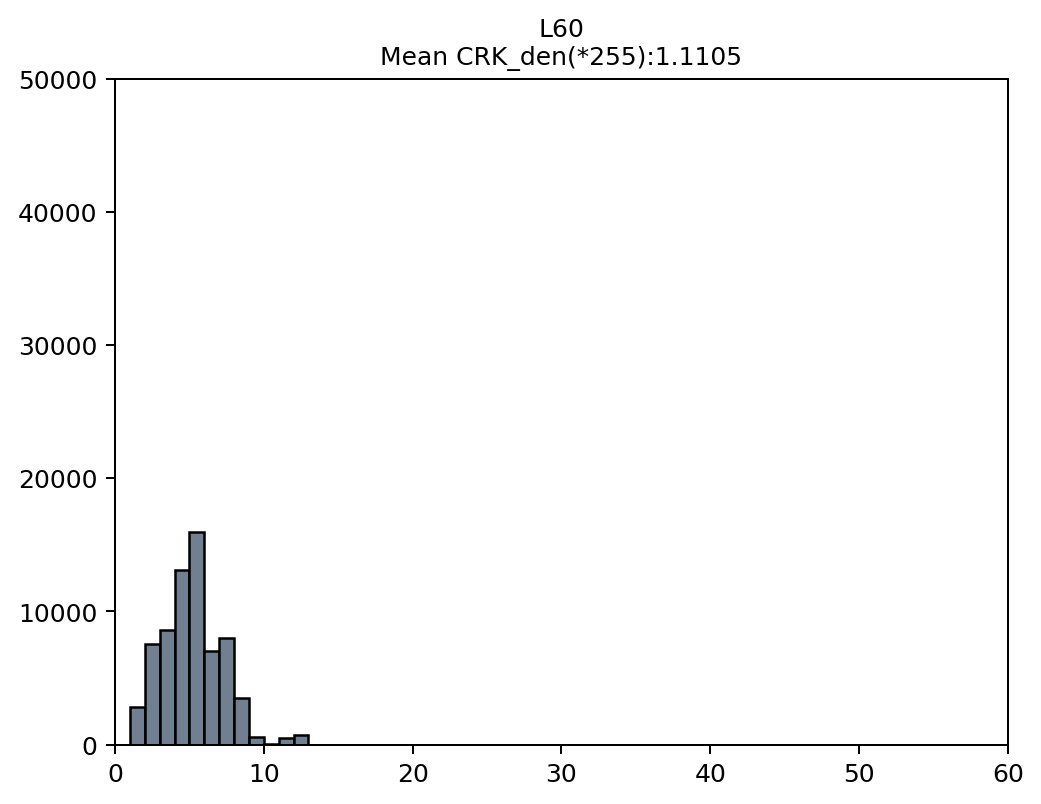

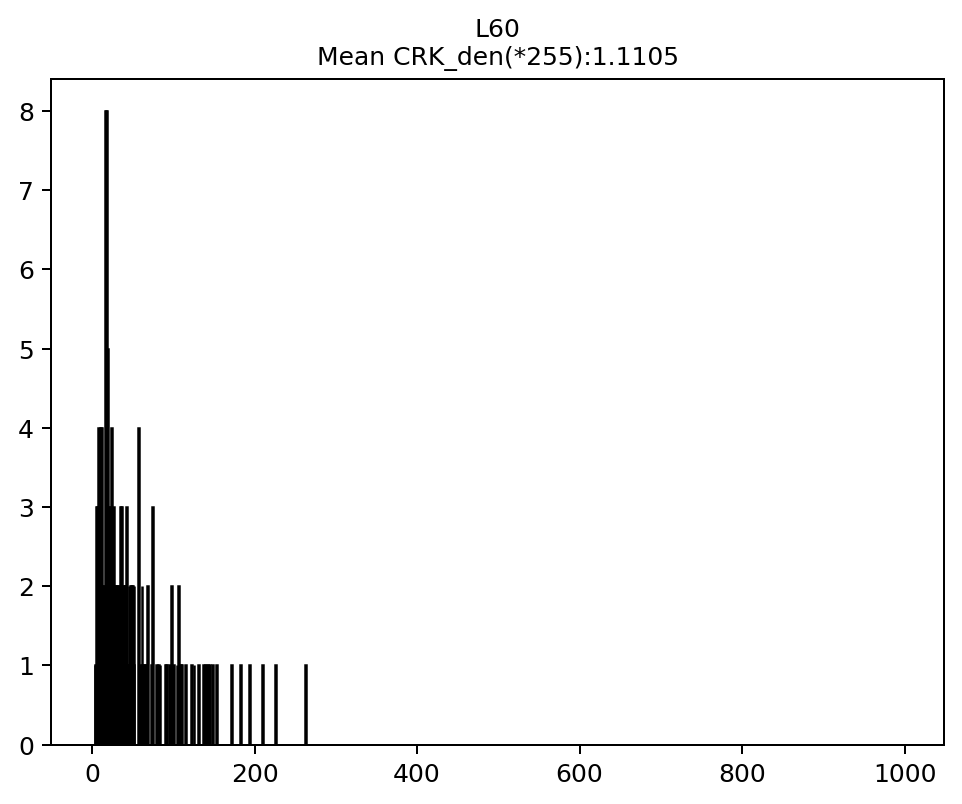

In [29]:
#Count width (Group average)
fig,ax1=plt.subplots(dpi=180)
means=[]
group_wplain=np.array([])
for i in range(len(width_imgplain)):
    nonzero_values = width_imgplain[i][width_imgplain[i]!= 0]
    group_wplain=np.concatenate([group_wplain,nonzero_values.ravel()])
    means.append(densityplain[i])
ax1.hist(group_wplain, bins=np.arange(0,60,1),color="slategray", edgecolor="black")
mean_v=np.mean(np.array(means))
ax1.set_title(f"L{i+1}\nMean CRK_den(*255):{mean_v:.4f}",fontsize=10)
ax1.set_xlim(0,60)
ax1.set_ylim(0,50000)
plt.savefig('Widthplain_smallset18_gen.png',bbox_inches='tight')
#Count width (Group average)
#Count width (Group average)
fig,ax1=plt.subplots(dpi=180)
means=[]
group_lplain=np.array([])

for k in range(len(length_imgplain)):
    #nonzero_values = length_img[i][j][k][length_img[i][j][k]!= 0]
    #group_l=np.concatenate([group_l,nonzero_values.ravel()])
    means.append(densityplain[k])
    area_vals = np.asarray(length_propplain[k]["area"])
    group_lplain=np.concatenate([group_lplain,area_vals])
print(group_lplain)
ax1.hist(group_lplain, bins=np.arange(0,1000,1), color="slategray", edgecolor="black")
mean_v=np.mean(np.array(means))
ax1.set_title(f"L{i+1}\nMean CRK_den(*255):{mean_v:.4f}",fontsize=10)
#ax1.set_xlim(0,1000)
#ax1.set_ylim(0,20)
plt.savefig('Lengthplain_smallset18_gen.png',bbox_inches='tight')    

Measure the thickness and distribution of cracks after manual segmentation

In [ ]:
resolution=20
thk,psd=meausure_thickness(im,resolution)   # input resolution in um/px
width_s=np.array(thk)*resolution
crack_area=np.count_nonzero(im)*(resolution**2)/1000000

  0%|          | 0/60 [00:00<?, ?it/s]

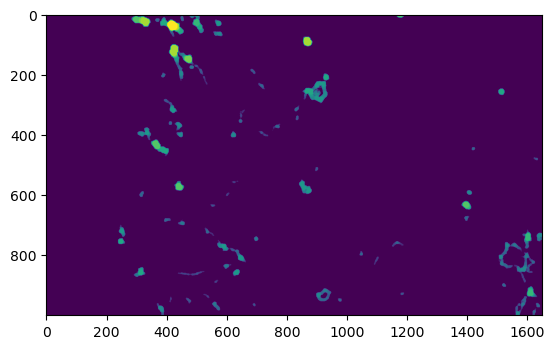

In [ ]:
plt.imshow(thk)

<BarContainer object of 10 artists>

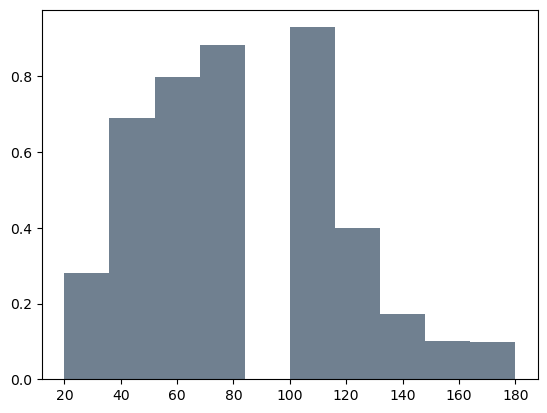

In [ ]:

plt.bar(psd.bin_centers,(np.array(psd.satn)*crack_area),psd.bin_widths,color='slategray')

In [61]:
"""""
plot length distribution
"""
skele=denoise_skeletonize(im)
table,img_l=measure_length(skele.astype('uint8'))
length__true=np.array(img_l*resolution)


Text(0.5, 0, 'length(um)')

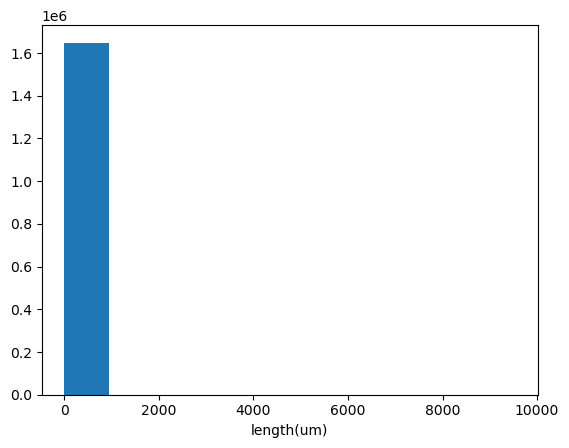

In [65]:
plt.hist(length__true.flatten())
plt.xlabel('length(um)')